# 1. Compiling the Dataset and Engineering Features

### Data Cleaning / Combining into DataFrame used in model training

First, we read in the 'labels' - hourly energy demand. Our analysis will focus on the load zone 'COAS', which includes Houston, TX. See the image below for reference (Coast).

<img src="https://www.ercot.com/files/assets/2023/04/26/Weather.jpg?" width="50%">


In [ ]:
import pandas as pd
import numpy as np

df_demand = pd.read_csv("ercot_demand.csv")
df_demand["period"] = pd.to_datetime(df_demand["period"])
df_demand.head()

,period,COAS,EAST,FWES,NCEN,NRTH,SCEN,SOUT,WEST
0,2023-06-01 00:00:00,17008.0,2373.0,5998.0,20016.0,1692.0,11267.0,5320.0,1712.0
1,2023-06-01 01:00:00,16423.0,2247.0,5964.0,19076.0,1681.0,10901.0,5135.0,1502.0
2,2023-06-01 02:00:00,15935.0,2122.0,5921.0,18104.0,1615.0,10416.0,4956.0,1408.0
3,2023-06-01 03:00:00,15387.0,2025.0,5980.0,17320.0,1550.0,10007.0,4804.0,1352.0
4,2023-06-01 04:00:00,14520.0,1885.0,5876.0,16056.0,1442.0,9321.0,4457.0,1337.0


To verify our import worked and the data looks good, we can plot a random week in the year.

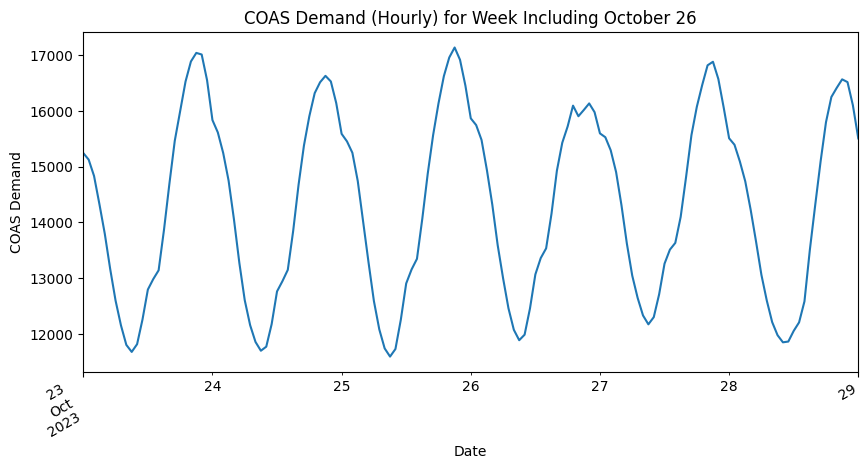

In [ ]:
df_demand_oct = df_demand[df_demand["period"].dt.month == 10]
# Find the monday-sunday week in October that includes October 26
oct_26 = df_demand_oct[df_demand_oct["period"].dt.day == 26].iloc[0]["period"]
start_of_week = oct_26 - pd.Timedelta(days=oct_26.dayofweek)  # Monday of the week
end_of_week = start_of_week + pd.Timedelta(days=6)  # Sunday of the week
df_demand_week = df_demand_oct[
    (df_demand_oct["period"] >= start_of_week) &
    (df_demand_oct["period"] <= end_of_week)
]

import matplotlib.dates as mdates

ax = df_demand_week.set_index("period")["COAS"].plot(figsize=(10, 5))
ax.set_xlabel("Date")
ax.set_ylabel("COAS Demand")
ax.set_title("COAS Demand (Hourly) for Week Including October 26")
ax.figure.autofmt_xdate()






Next, we import weather data. This file contains data for weather predictions at the time instead of the actual weather to ensure fairness with ERCOTs model.

In [ ]:
df_fair_weather = pd.read_csv("WeatherPredictions/HoustonWeat.csv")
df_fair_weather.columns = df_fair_weather.columns.str.strip()

df_fair_weather.head()

# Convert to datetime
df_fair_weather['runtime'] = pd.to_datetime(df_fair_weather['runtime'])
df_fair_weather['ftime'] = pd.to_datetime(df_fair_weather['ftime'])

# 1. Filter for Day-Ahead Fairness (12 UTC run, looking 12 to 40 hours ahead)
df_fair_weather['horizon'] = df_fair_weather['ftime'] - df_fair_weather['runtime']
df_da = df_fair_weather[
    (df_fair_weather['runtime'].dt.hour == 12) &
    (df_fair_weather['horizon'] >= pd.Timedelta(hours=12)) &
    (df_fair_weather['horizon'] <= pd.Timedelta(hours=40))
].copy()

# 2. Updated renaming to include snow (if available in MOS)
df_da = df_da[['ftime', 'tmp', 'dpt', 'snw']].rename(columns={
    'ftime': 'valid',
    'tmp': 'tmpf',
    'dpt': 'dwpf',
    'snw': 'snowdepth'
})
df_da = df_da.drop_duplicates(subset=['valid'])

# 3. Interpolate 3-hour MOS data into hourly data
df_weather = df_da.set_index('valid').resample('h').interpolate(method='linear').reset_index()

df_weather.head()

,valid,tmpf,dwpf,snowdepth
0,2023-06-02 00:00:00,80.000000,67.000000,NaN
1,2023-06-02 01:00:00,78.000000,67.333333,NaN
2,2023-06-02 02:00:00,76.000000,67.666667,NaN
3,2023-06-02 03:00:00,74.000000,68.000000,NaN
4,2023-06-02 04:00:00,73.333333,68.000000,NaN


Below this are the two new data files that contain weather prediction information for Beaumont and Galveston.

In [ ]:
df_fair_weather = pd.read_csv("WeatherPredictions/BeaumontWeat.csv")
df_fair_weather.columns = df_fair_weather.columns.str.strip()

df_fair_weather.head()

,runtime,ftime,model,n_x,tmp,dpt,cld,wdr,wsp,p06,...,snw,cig,vis,obv,poz,pos,typ,station,t06,t12
0,2023-06-01 12:00:00,2023-06-01 18:00:00,GFS,NaN,86,65,SC,130,6,NaN,...,NaN,8,7,N,NaN,NaN,NaN,KBPT,NaN,NaN
1,2023-06-01 12:00:00,2023-06-01 21:00:00,GFS,NaN,85,65,BK,160,7,NaN,...,NaN,8,7,N,NaN,NaN,NaN,KBPT,NaN,NaN
2,2023-06-01 12:00:00,2023-06-02 00:00:00,GFS,NaN,81,66,BK,200,5,4.0,...,NaN,8,7,N,NaN,NaN,NaN,KBPT,17/0,NaN
3,2023-06-01 12:00:00,2023-06-02 03:00:00,GFS,NaN,74,69,CL,0,0,NaN,...,NaN,8,7,N,NaN,NaN,NaN,KBPT,NaN,NaN
4,2023-06-01 12:00:00,2023-06-02 06:00:00,GFS,NaN,72,69,CL,0,0,4.0,...,NaN,8,7,N,NaN,NaN,NaN,KBPT,7/0,NaN


In [ ]:
df_fair_weather = pd.read_csv("WeatherPredictions/GalvestonWeat.csv")
df_fair_weather.columns = df_fair_weather.columns.str.strip()

display(df_fair_weather)

,runtime,ftime,model,n_x,tmp,dpt,cld,wdr,wsp,p06,...,snw,cig,vis,obv,poz,pos,typ,station,t06,t12
0,2023-06-01 12:00:00,2023-06-01 18:00:00,GFS,NaN,86,70,SC,140,10,NaN,...,NaN,8,7,N,NaN,NaN,NaN,KGLS,NaN,NaN
1,2023-06-01 12:00:00,2023-06-01 21:00:00,GFS,NaN,86,69,FW,140,10,NaN,...,NaN,8,7,N,NaN,NaN,NaN,KGLS,NaN,NaN
2,2023-06-01 12:00:00,2023-06-02 00:00:00,GFS,NaN,83,69,FW,140,8,0.0,...,NaN,8,7,N,NaN,NaN,NaN,KGLS,4/0,NaN
3,2023-06-01 12:00:00,2023-06-02 03:00:00,GFS,NaN,79,69,CL,160,5,NaN,...,NaN,8,7,N,NaN,NaN,NaN,KGLS,NaN,NaN
4,2023-06-01 12:00:00,2023-06-02 06:00:00,GFS,NaN,78,70,CL,110,3,2.0,...,NaN,8,7,N,NaN,NaN,NaN,KGLS,0/0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30676,2024-05-31 12:00:00,2024-06-02 18:00:00,GFS,NaN,86,78,BK,160,14,14.0,...,NaN,6,7,N,0.0,0.0,R,KGLS,18/7,NaN
30677,2024-05-31 12:00:00,2024-06-02 21:00:00,GFS,NaN,87,78,BK,150,13,NaN,...,NaN,6,7,N,0.0,0.0,R,KGLS,NaN,NaN
30678,2024-05-31 12:00:00,2024-06-03 00:00:00,GFS,89.0,84,78,SC,150,12,23.0,...,NaN,7,7,N,0.0,0.0,R,KGLS,18/6,NaN
30679,2024-05-31 12:00:00,2024-06-03 06:00:00,GFS,NaN,83,78,BK,150,15,5.0,...,NaN,6,7,N,1.0,0.0,R,KGLS,6/3,NaN


Next is the simple file that lists recognized federal holidays.

In [ ]:
df_fair_weather = pd.read_csv("FedHolidays.csv")

display(df_fair_weather)

,holiday_name,date
0,New Year’s Day,2023-01-02
1,"Birthday of Martin Luther King, Jr.",2023-01-16
2,Washington’s Birthday,2023-02-20
3,Memorial Day,2023-05-29
4,Juneteenth National Independence Day,2023-06-19
5,Independence Day,2023-07-04
6,Labor Day,2023-09-04
7,Columbus Day,2023-10-09
8,Veterans Day,2023-11-10
9,Thanksgiving Day,2023-11-23


In [ ]:
df_fair_weather = pd.read_csv("Houston_BtmSolar_Combined.csv")
display(df_fair_weather)



,Load_Zone,Solar_under_50kW,Solar_over_50kW,Wind_under_50kW,Wind_over_50kW,Other_Renewable_under_50kW,Other_Renewable_over_50kW,Other_NonRenewable_under_50kW,Other_NonRenewable_over_50kW,Total_under_50kW,Total_over_50kW,Combined_Total,Reporting_Period
0,LZ_AEN,93.650000,29.240000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,93.650000,29.240000,122.890000,2023Q4
1,LZ_CPS,322.900000,88.007000,0.010000,0.00000,11.990000,0.0000,0.000000,19.81000,334.900000,107.817000,442.717000,2023Q4
2,LZ_HOUSTON,306.011596,4.118020,0.362382,0.00000,0.853360,0.1120,0.384584,4.29500,307.611922,8.525020,316.136942,2023Q4
3,LZ_LCRA,124.509191,29.156615,0.203450,0.00000,4.535713,1.3352,2.365000,0.00000,131.613354,30.491815,162.105169,2023Q4
4,LZ_NORTH,819.178393,49.880269,2.034424,1.00600,0.500500,0.2400,14.985220,4.92069,836.698537,56.046959,892.745496,2023Q4
5,LZ_RAYBN,62.162000,8.010000,0.293000,0.00000,0.000000,0.0000,0.000000,0.00000,62.455000,8.010000,70.465000,2023Q4
6,LZ_SOUTH,297.417550,40.946670,12.413695,0.55720,0.030000,0.0000,3.632315,0.00000,313.493560,41.503870,354.997430,2023Q4
7,LZ_WEST,114.532521,11.387410,3.747364,10.30083,0.062600,0.0000,0.327970,0.33924,118.670455,22.027480,140.697935,2023Q4
8,ERCOT PUBLIC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023Q4
9,LZ_AEN,87.090000,29.190000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,87.090000,29.190000,116.280000,2023Q2


The type of day (school day, school holiday but workday, weekend, etc) may influence energy consumption patterns as well. Hence we import [Houston's school district calendar](https://www.fox26houston.com/news/houston-isd-calendar-for-2023-2024-academic-school-year-updated-released)

In [ ]:
df_calendar = pd.read_csv('hisd_2023_2024_day_categories_with_business(1).csv')
df_calendar.head()

,day,school_category,business_category
0,2023-06-01,summer_break_weekday,normal_business_day
1,2023-06-02,summer_break_weekday,normal_business_day
2,2023-06-03,weekend_school_break,weekend
3,2023-06-04,weekend_school_break,weekend
4,2023-06-05,summer_break_weekday,normal_business_day


Now that we have gathered all relevant data, we combine the datasets into one DataFrame.

In [ ]:
# Standardize date columns for merging
df_calendar['day'] = pd.to_datetime(df_calendar['day'])
df_weather['valid'] = pd.to_datetime(df_weather['valid'])

# Initialize the combined dataframe with the demand labels (COAS)
df_final = df_demand[['period', 'COAS']].copy()

# Merge daily calendar data
df_final['date_key'] = df_final['period'].dt.normalize()
df_final = df_final.merge(df_calendar, left_on='date_key', right_on='day', how='left')

# Merge weather data (using 'h' instead of 'H' to avoid FutureWarning)
weather_hourly = df_weather.groupby(df_weather['valid'].dt.floor('h')).mean(numeric_only=True).reset_index()
df_final = df_final.merge(weather_hourly, left_on='period', right_on='valid', how='left')

# Clean up temporary columns used for merging
df_final = df_final.drop(columns=['date_key', 'day', 'valid'])

df_final.head()

,period,COAS,school_category,business_category,tmpf,dwpf,snowdepth
0,2023-06-01 00:00:00,17008.0,summer_break_weekday,normal_business_day,NaN,NaN,NaN
1,2023-06-01 01:00:00,16423.0,summer_break_weekday,normal_business_day,NaN,NaN,NaN
2,2023-06-01 02:00:00,15935.0,summer_break_weekday,normal_business_day,NaN,NaN,NaN
3,2023-06-01 03:00:00,15387.0,summer_break_weekday,normal_business_day,NaN,NaN,NaN
4,2023-06-01 04:00:00,14520.0,summer_break_weekday,normal_business_day,NaN,NaN,NaN


Now that the data is all in one place, we can clean and apply some preprocessing for our machine learning models. One noteworthy preprocessing step is encoding the week as a cyclical variable to capture the adjacency between a Monday and the following Monday, since these are the most telling of people's perdicted behaviors

In [ ]:
# Drop nonsensical, redundant, and observation-only features
# - lat/lon: nonsensical for model
# - feel/mslp: highly correlated/redundant
# - alti, skyl1-4, ice_accretion_*, peak_wind_*, metar: observation-only, not available in forecasts
cols_to_drop = [
    'lon', 'lat', 'feel', 'mslp',
    'alti',
    'skyl1', 'skyl2', 'skyl3', 'skyl4',
    'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr',
    'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time',
    'metar'
]
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

# Datetime conversion (extract features and set index)
# Encode hour cyclically so that hour 23 and 0 are adjacent
# Cyclical encoding for hour, day_of_week, and month
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['period'].dt.hour / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final['period'].dt.hour / 24)

# day of week and month
df_final['day_of_week'] = df_final['period'].dt.dayofweek
df_final['month'] = df_final['period'].dt.month

df_final = df_final.set_index('period')

# Categorical encoding
df_final = pd.get_dummies(df_final, columns=['school_category', 'business_category'], drop_first=True)

# Missing values
df_final['snowdepth'] = df_final['snowdepth'].fillna(0)
df_final = df_final.ffill()

# Time-series lag features
# Switching to a 48-hour lag ensures the model only uses demand actuals
# that were known before the Day-Ahead forecast was published.
df_final['COAS_lag_48h'] = df_final['COAS'].shift(48)
df_final['COAS_lag_168h'] = df_final['COAS'].shift(168)

# Rolling 48-hour average temperature
df_final['tmpf_roll_48h'] = df_final['tmpf'].rolling(window=48).mean()

# Interaction terms (Temperature x Business categories)
df_final['tmpf_x_normal_biz'] = df_final['tmpf'] * df_final['business_category_normal_business_day']
df_final['tmpf_x_weekend'] = df_final['tmpf'] * df_final['business_category_weekend']


# Returned and added these later on after K-means clustering showed the model struggled more on warmer days than cooler ones.
# --- Non-linear Temperature Features ---

# 1. Cooling Degree (Base 65°F)
# Calculates degrees above 65; sets anything below 65 to 0.
df_final['CDD_65'] = (df_final['tmpf'] - 65).clip(lower=0)

# 2. Temperature Squared
# Punishes the model's loss function more heavily for extreme temperature values
df_final['tmpf_squared'] = df_final['tmpf'] ** 2

# 3. Prolonged Heat Feature
# Buildings retain heat; a 48-hour rolling average of CDD captures the "thermal mass" effect of sustained heatwaves
df_final['CDD_roll_48h'] = df_final['CDD_65'].rolling(window=48).mean()

# Drop all NaNs created by the 168h/48h lags and the 48h rolling windows
df_final = df_final.dropna(subset=['COAS_lag_168h', 'tmpf_roll_48h', 'CDD_roll_48h', 'COAS_lag_48h'])

df = df_final.copy()
df.head()

,COAS,tmpf,dwpf,snowdepth,hour_sin,hour_cos,day_of_week,month,school_category_regular_school_day,school_category_spring_break_weekday,...,business_category_partial_business_closure,business_category_weekend,COAS_lag_48h,COAS_lag_168h,tmpf_roll_48h,tmpf_x_normal_biz,tmpf_x_weekend,CDD_65,tmpf_squared,CDD_roll_48h
period,,,,,,,,,,,,,,,,,,,,,
2023-06-08 00:00:00,17214.0,85.000000,67.000000,0.0,0.000000,1.000000,3,6,False,False,...,False,False,13684.0,17008.0,75.895833,85.000000,0.0,20.000000,7225.000000,10.895833
2023-06-08 01:00:00,16426.0,82.333333,67.666667,0.0,0.258819,0.965926,3,6,False,False,...,False,False,13369.0,16423.0,76.048611,82.333333,0.0,17.333333,6778.777778,11.048611
2023-06-08 02:00:00,16064.0,79.666667,68.333333,0.0,0.500000,0.866025,3,6,False,False,...,False,False,13327.0,15935.0,76.187500,79.666667,0.0,14.666667,6346.777778,11.187500
2023-06-08 03:00:00,15608.0,77.000000,69.000000,0.0,0.707107,0.707107,3,6,False,False,...,False,False,13169.0,15387.0,76.312500,77.000000,0.0,12.000000,5929.000000,11.312500
2023-06-08 04:00:00,14755.0,75.666667,69.000000,0.0,0.866025,0.500000,3,6,False,False,...,False,False,12623.0,14520.0,76.437500,75.666667,0.0,10.666667,5725.444444,11.437500


# 2. Implementing, Tuning, and Evaluating the Model


REMINDER FOR MYSELF TO COME BACK LATER AND DESCRIBE OUR TESTING PROCESS


## Model: XGBoost

XGBoost performs very well with non-linear relationships and tabular data, and is known to be efficient for time-series datasets. Hyperparameters were tuned using grid search (for clarity, this is not included in this notebook).

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Data
y = df['COAS']
X = df.drop(columns=['COAS'])

# 2. Initialize the Model
best_xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror',
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42
)

# 3. Walk-Forward Validation (Fair Testing)
tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

print("Starting Walk-Forward Validation...")

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    best_xgb_model.fit(X_train_fold, y_train_fold)

    fold_preds = best_xgb_model.predict(X_test_fold)
    fold_mae = mean_absolute_error(y_test_fold, fold_preds)
    mae_scores.append(fold_mae)

    print(f"Fold {i+1}: {X_test_fold.index.min().date()} to {X_test_fold.index.max().date()} | MAE: {fold_mae:.2f} MW")

print(f"\nAverage Walk-Forward MAE: {np.mean(mae_scores):.2f} MW")

# 4. Final Train for Comparison (Using your original 80/20 split for the ERCOT chart)
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

best_xgb_model.fit(X_train, y_train)
y_pred = best_xgb_model.predict(X_test)

Starting Walk-Forward Validation...
Fold 1: 2023-08-06 to 2023-10-05 | MAE: 578.45 MW
Fold 2: 2023-10-05 to 2023-12-04 | MAE: 1339.93 MW
Fold 3: 2023-12-04 to 2024-02-02 | MAE: 693.87 MW
Fold 4: 2024-02-02 to 2024-04-02 | MAE: 338.52 MW
Fold 5: 2024-04-02 to 2024-05-31 | MAE: 597.88 MW

Average Walk-Forward MAE: 709.73 MW


XGBoost is very accurate, as shown later on visually in the figure as well as by the lower MAE.

# 2. Comparing our model's predictions to ERCOT's predictions

ERCOT releases electricity demand forecasts across several horizons. Since one of the features used in our models is energy demand 48h previously, we will compare our predictions to ERCOT's day-ahead predictions.

We start by importing and extracting ERCOT's day-ahead predictions. Notably, they are posted on a different timezone, so we shift the timestamps to align with our previous analysis.

In [ ]:
# ── Step 1: Load ERCOT day-ahead forecast and align with our test set ────────

df_ercot_raw = pd.read_csv("ercot_forecast_wide.csv")

# Convert hour-ending to hour-beginning timestamps in Central Time, then to UTC
hours_offset = df_ercot_raw["hourEnding"].astype(str).str.split(":").str[0].astype(int) - 1
local_period = pd.to_datetime(df_ercot_raw["deliveryDate"]) + pd.to_timedelta(hours_offset, unit="h")

# Localize to Central, convert to UTC, then strip tz to match df_final's naive index
df_ercot_raw["period"] = (
    local_period
    .dt.tz_localize("US/Central", ambiguous="NaT", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

df_ercot_raw["Posted"] = pd.to_datetime(df_ercot_raw["postedDatetime"], format="mixed")

# Forecast horizon = delivery time − posting time
df_ercot_raw["Horizon"] = df_ercot_raw["period"] - df_ercot_raw["Posted"]

# Keep only day-ahead forecasts (horizon ≈ 48 h, window 18–30 h)
df_da = df_ercot_raw[
    (df_ercot_raw["Horizon"] >= pd.Timedelta(hours=42))
    & (df_ercot_raw["Horizon"] <= pd.Timedelta(hours=54))
].copy()

# For each delivery hour, pick the forecast closest to exactly 24 h ahead
df_da["Horizon_Error"] = abs(df_da["Horizon"] - pd.Timedelta(hours=48))
df_da = df_da.sort_values("Horizon_Error").drop_duplicates(subset=["period"])

# Final formatting — keep coast column aligned to test-set index
ercot_forecast = (
    df_da[["period", "coast"]]
    .rename(columns={"coast": "ercot_forecast"})
    .set_index("period")
    .sort_index()
)

# Strip tz if needed to match df_final
if df_final.index.tz is None and ercot_forecast.index.tz is not None:
    ercot_forecast.index = ercot_forecast.index.tz_localize(None)

# Restrict to test-set hours
ercot_forecast = ercot_forecast.loc[ercot_forecast.index.isin(y_test.index)]

print(f"Test set hours:           {len(y_test)}")
print(f"ERCOT forecasts matched:  {len(ercot_forecast)}")
print(f"Test set range:           {y_test.index.min()} → {y_test.index.max()}")
print(f"ERCOT matched range:      {ercot_forecast.index.min()} → {ercot_forecast.index.max()}")
ercot_forecast.head()

Test set hours:           1724
ERCOT forecasts matched:  1724
Test set range:           2024-03-21 04:00:00 → 2024-05-31 23:00:00
ERCOT matched range:      2024-03-21 04:00:00 → 2024-05-31 23:00:00


,ercot_forecast
period,
2024-03-21 04:00:00,10569.5000
2024-03-21 05:00:00,10106.4004
2024-03-21 06:00:00,9766.0801
2024-03-21 07:00:00,9538.9004
2024-03-21 08:00:00,9449.0498


We now compare our model's predictions to ERCOT's predictions.

Hours compared:    1724
XGBoost MAE:       542.3 MW
ERCOT   MAE:       698.2 MW
XGBoost win rate:  58.6%



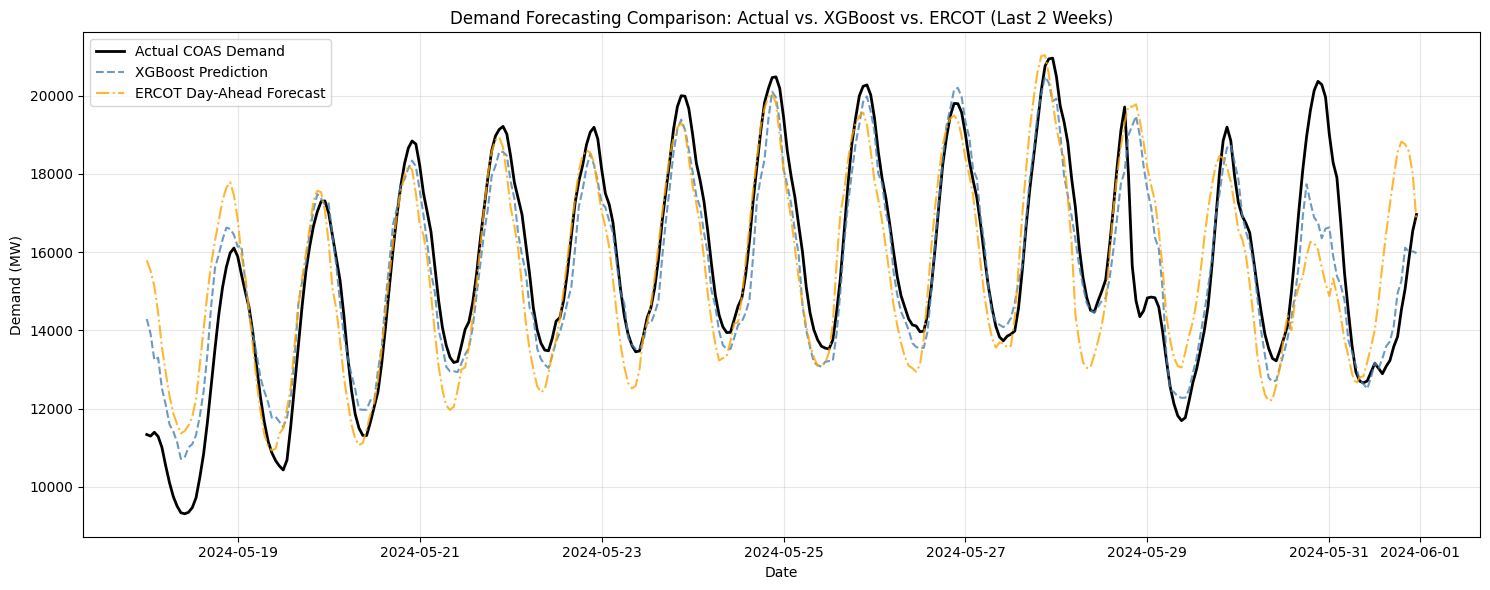

In [ ]:
# ── Step 2: Compute error vectors and plot last 2 weeks ─────────────────────
# Build aligned comparison DataFrame
error_df = pd.DataFrame({
    "actual": y_test,
    "xgb_pred": y_pred, # Using the predictions from best_xgb_model
}).join(ercot_forecast, how="inner")

error_df["xgb_error"]  = error_df["xgb_pred"] - error_df["actual"]
error_df["ercot_error"] = error_df["ercot_forecast"] - error_df["actual"]

error_df["abs_xgb_error"]  = error_df["xgb_error"].abs()
error_df["abs_ercot_error"] = error_df["ercot_error"].abs()

error_df["xgb_wins"] = (error_df["abs_xgb_error"] < error_df["abs_ercot_error"]).astype(int)

xgb_mae  = error_df["abs_xgb_error"].mean()
ercot_mae = error_df["abs_ercot_error"].mean()
win_rate  = error_df["xgb_wins"].mean() * 100

print(f"Hours compared:    {len(error_df)}")
print(f"XGBoost MAE:       {xgb_mae:.1f} MW")
print(f"ERCOT   MAE:       {ercot_mae:.1f} MW")
print(f"XGBoost win rate:  {win_rate:.1f}%\n")

# ── Plot last 2 weeks: Actual vs XGBoost vs ERCOT Day-Ahead ────────────────
hours_to_plot = 24 * 14
plot_slice = error_df.iloc[-hours_to_plot:]

plt.figure(figsize=(15, 6))
plt.plot(plot_slice.index, plot_slice["actual"], label="Actual COAS Demand", color="black", linewidth=2)
plt.plot(plot_slice.index, plot_slice["xgb_pred"], label="XGBoost Prediction", color="steelblue", alpha=0.8, linestyle="--")
plt.plot(plot_slice.index, plot_slice["ercot_forecast"], label="ERCOT Day-Ahead Forecast", color="orange", alpha=0.8, linestyle="-.")

plt.title("Demand Forecasting Comparison: Actual vs. XGBoost vs. ERCOT (Last 2 Weeks)")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Analyzing error patterns

We first graph out our most telling features, these contribute the most to our predictions and are fairly intuitive.

<Figure size 1000x800 with 0 Axes>

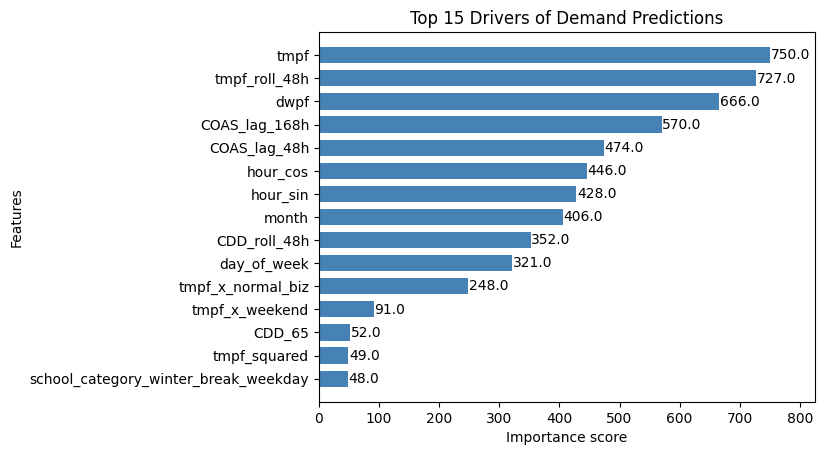

In [ ]:
# Feature Importance Plot
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb_model, max_num_features=15, height=0.7, color='steelblue', grid=False)
plt.title("Top 15 Drivers of Demand Predictions")
plt.show()

Then we plot the hourly head-to-head victor between our XGBoost model and the ERCOT prediction.

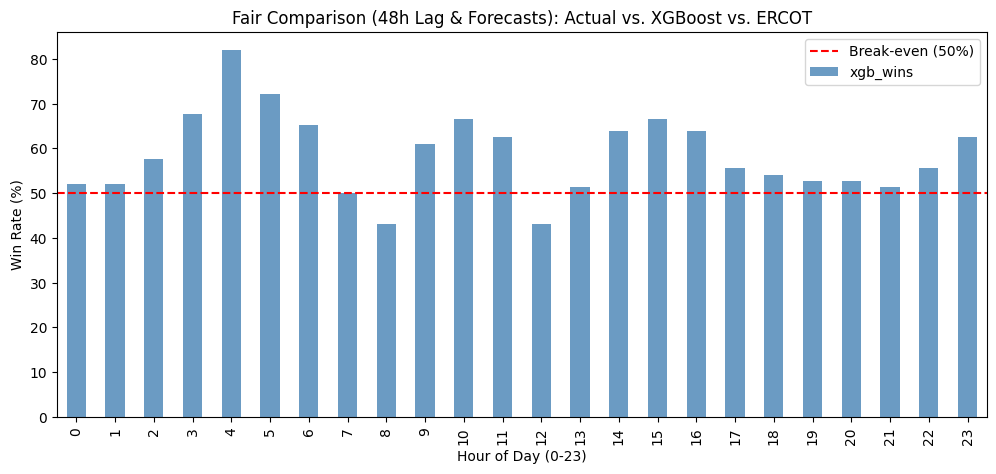

In [ ]:
# Hourly Win Rate
error_df['hour'] = error_df.index.hour
hourly_win_rate = error_df.groupby('hour')['xgb_wins'].mean() * 100

plt.figure(figsize=(12, 5))
hourly_win_rate.plot(kind='bar', color='steelblue', alpha=0.8)
plt.axhline(50, color='red', linestyle='--', label='Break-even (50%)')
plt.title("Fair Comparison (48h Lag & Forecasts): Actual vs. XGBoost vs. ERCOT")
plt.ylabel("Win Rate (%)")
plt.xlabel("Hour of Day (0-23)")
plt.legend()
plt.show()

This plot is basically a "stress test" for the models.

**AI explanation**:
Our model achieved an R² of 0.899, while ERCOT sits at 0.825. In simple terms, this means our model explains roughly 90% of the variance in demand, whereas ERCOT only explains about 82%


**Our Model (Left)**: The blue dots are more tightly hugged against the red line. This suggests that our errors are consistent and smaller.

**ERCOT (Right)**: The orange dots show more vertical "smearing," especially in the middle-demand range. This indicates that for the same actual load level, ERCOT’s model produces a wider range of incorrect guesses.

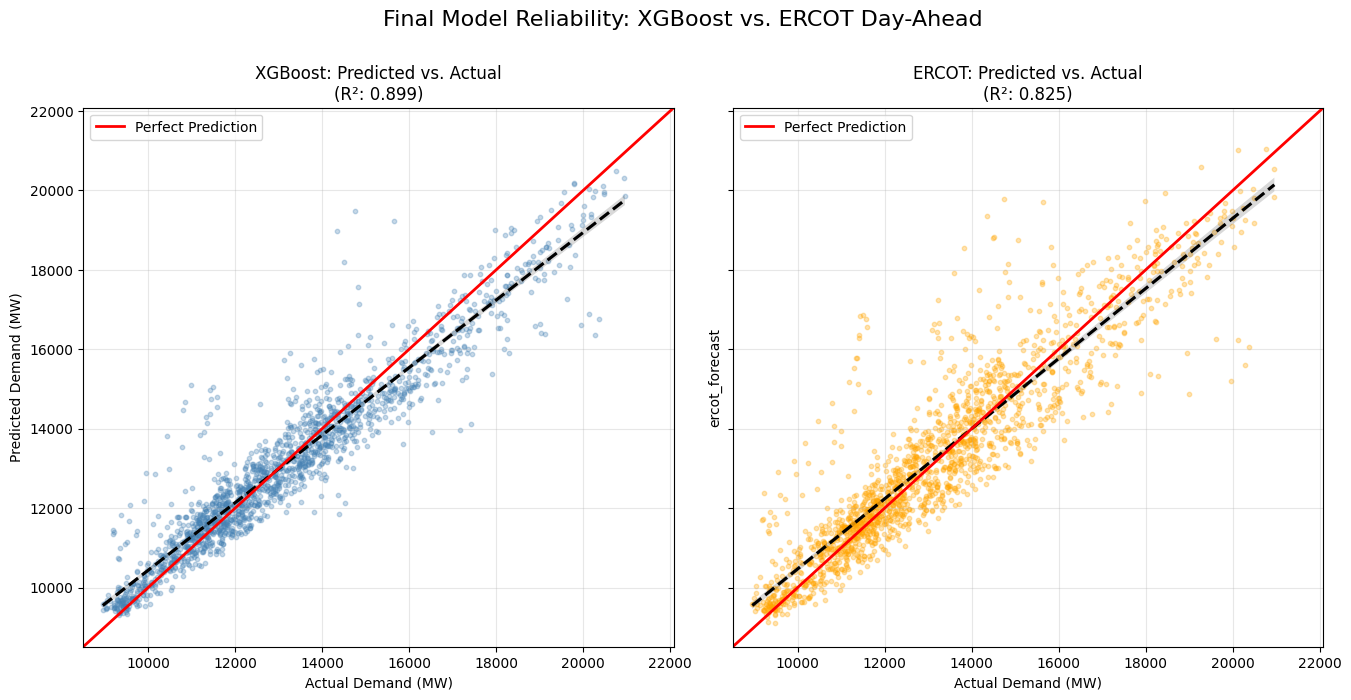

--- Peak Demand Analysis (Top 10% of Loads > 16723 MW) ---
XGBoost Peak MAE: 898.1 MW
ERCOT Peak MAE:   914.9 MW
Improvement:      1.8%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 1. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.1)

# Define plot limits for a perfect square comparison
min_val = min(error_df['actual'].min(), error_df['xgb_pred'].min(), error_df['ercot_forecast'].min()) * 0.95
max_val = max(error_df['actual'].max(), error_df['xgb_pred'].max(), error_df['ercot_forecast'].max()) * 1.05

# 2. XGBoost Scatter Plot
sns.regplot(x='actual', y='xgb_pred', data=error_df, ax=ax1,
            scatter_kws={'alpha':0.3, 'color':'steelblue', 's':10},
            line_kws={'color':'black', 'linestyle':'--'})
ax1.set_title(f"XGBoost: Predicted vs. Actual\n(R²: {r2_score(error_df['actual'], error_df['xgb_pred']):.3f})")
ax1.set_xlabel("Actual Demand (MW)")
ax1.set_ylabel("Predicted Demand (MW)")

# 3. ERCOT Scatter Plot
sns.regplot(x='actual', y='ercot_forecast', data=error_df, ax=ax2,
            scatter_kws={'alpha':0.3, 'color':'orange', 's':10},
            line_kws={'color':'black', 'linestyle':'--'})
ax2.set_title(f"ERCOT: Predicted vs. Actual\n(R²: {r2_score(error_df['actual'], error_df['ercot_forecast']):.3f})")
ax2.set_xlabel("Actual Demand (MW)")

# 4. Add "Perfect Prediction" Identity Lines
for ax in [ax1, ax2]:
    ax.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, label='Perfect Prediction')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Final Model Reliability: XGBoost vs. ERCOT Day-Ahead", fontsize=16, y=1.02)
plt.show()

# 5. Print a Peak-Load Gap Analysis
peak_threshold = error_df['actual'].quantile(0.90)
xgb_peak_mae = error_df[error_df['actual'] > peak_threshold]['abs_xgb_error'].mean()
ercot_peak_mae = error_df[error_df['actual'] > peak_threshold]['abs_ercot_error'].mean()

print(f"--- Peak Demand Analysis (Top 10% of Loads > {peak_threshold:.0f} MW) ---")
print(f"XGBoost Peak MAE: {xgb_peak_mae:.1f} MW")
print(f"ERCOT Peak MAE:   {ercot_peak_mae:.1f} MW")
print(f"Improvement:      {((ercot_peak_mae - xgb_peak_mae) / ercot_peak_mae)*100:.1f}%")